# Visualizing results.json Data

This notebook reads and visualizes the evaluation results stored in `results/results.json`, comparing the baseline approach with the tokensaver approach across various metrics.


## 1. Import Required Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load JSON Data
Read the data from `results/results.json`.

In [2]:
with open('results/results.json') as f:
    raw_data = json.load(f)

tasks = {k: v for k, v in raw_data.items() if not k.startswith('_')}
print(f"Loaded {len(tasks)} tasks.")

Loaded 30 tasks.


## 3. Preprocess Data into DataFrame

In [3]:
TOKEN_COLS = ['input_tokens', 'cache_creation_input_tokens', 'cache_read_input_tokens',
              'output_tokens', 'total_tokens', 'n_turns', 'intent_score']

def parse_checklist(value):
    if not value:
        return None
    passed, total = map(int, value.split('/'))
    return passed / total * 100 if total > 0 else None

records = [
    {
        'task_id': task_id,
        'condition': condition,
        **{col: metrics.get(col, 0) for col in TOKEN_COLS},
        'checklist_pct': parse_checklist(metrics.get('checklist')),
    }
    for task_id, conditions in tasks.items()
    for condition, metrics in conditions.items()
]

df = pd.DataFrame(records)
df.head()

,task_id,condition,input_tokens,cache_creation_input_tokens,cache_read_input_tokens,output_tokens,total_tokens,n_turns,intent_score,checklist_pct
0,08ec77ee77934f20,baseline,4,12572,23326,1718,14294,2,4,100.000000
1,08ec77ee77934f20,tokensaver,4,12612,23326,1248,13864,2,4,100.000000
2,10e4408e92944017,baseline,11,21369,130565,7288,28668,8,4,58.333333
3,10e4408e92944017,tokensaver,11,20886,130221,6755,27652,8,4,100.000000
4,19a3d90b4b2441d7,baseline,15,33612,199004,22732,56359,12,4,68.750000


## 4. Tradeoff Analysis: Token Savings vs Quality

In [4]:
df_pivot = df.pivot(index='task_id', columns='condition')
df_pivot.columns = [f"{cond}_{metric}" for metric, cond in df_pivot.columns]
df_pivot = df_pivot.reset_index().dropna(subset=['baseline_output_tokens', 'tokensaver_output_tokens'])

df_pivot['output_savings_abs'] = df_pivot['baseline_output_tokens'] - df_pivot['tokensaver_output_tokens']
df_pivot['output_savings_pct'] = df_pivot['output_savings_abs'] / df_pivot['baseline_output_tokens'] * 100
df_pivot['checklist_delta'] = df_pivot['tokensaver_checklist_pct'] - df_pivot['baseline_checklist_pct']

avg_b = df_pivot['baseline_output_tokens'].mean()
avg_t = df_pivot['tokensaver_output_tokens'].mean()
print(f"Avg output tokens — baseline: {avg_b:.0f}, tokensaver: {avg_t:.0f} ({(avg_t - avg_b) / avg_b * 100:+.1f}%)")

Avg output tokens — baseline: 8015, tokensaver: 5923 (-26.1%)


/var/folders/69/yq0yl5cs3zv0ftzrc82fryyc0000gn/T/ipykernel_96996/3872941208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='condition', y='output_tokens', ax=ax, errorbar='ci', capsize=.1, palette='Set2')


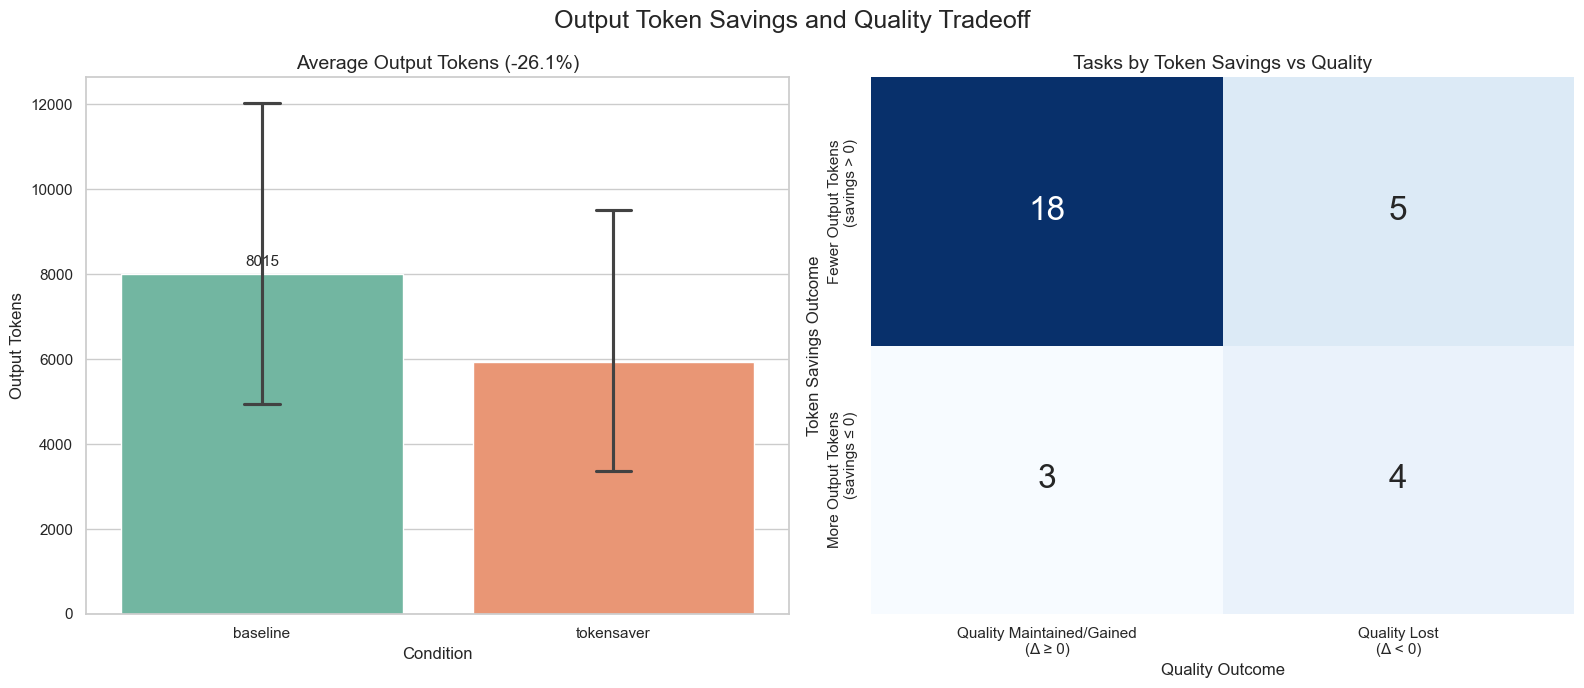

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Output Token Savings and Quality Tradeoff', fontsize=18)

# Average output tokens per condition
ax = axes[0]
sns.barplot(data=df, x='condition', y='output_tokens', ax=ax, errorbar='ci', capsize=.1, palette='Set2')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, size=11)
ax.set_title(f'Average Output Tokens ({(avg_t - avg_b) / avg_b * 100:+.1f}%)', fontsize=14)
ax.set(xlabel='Condition', ylabel='Output Tokens')

# 2x2 quadrant: token savings vs quality
ax = axes[1]
saved = df_pivot['output_savings_abs'] > 0
improved = df_pivot['checklist_delta'] >= 0
quadrant = np.array([
    [len(df_pivot[ saved &  improved]), len(df_pivot[ saved & ~improved])],
    [len(df_pivot[~saved &  improved]), len(df_pivot[~saved & ~improved])],
])
sns.heatmap(quadrant, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Quality Maintained/Gained\n(Δ ≥ 0)', 'Quality Lost\n(Δ < 0)'],
            yticklabels=['Fewer Output Tokens\n(savings > 0)', 'More Output Tokens\n(savings ≤ 0)'],
            annot_kws={'size': 24})
ax.set_title('Tasks by Token Savings vs Quality', fontsize=14)
ax.set(xlabel='Quality Outcome', ylabel='Token Savings Outcome')

plt.tight_layout()
plt.show()